# EfficientNet-B0 with Entropy, Ordinal, Focal Loss, and Deformable Convolutions

This notebook trains an EfficientNet-B0 model combining four advanced techniques:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance
- **Deformable Convolutions**: Adaptive spatial sampling for better feature extraction

## Deformable Convolutions

Deformable convolutions add 2D offsets to regular grid sampling locations in standard convolutions, allowing the receptive field to adaptively deform based on the input. This is particularly useful for medical images where:
- Tissue structures have irregular shapes
- Important features may not align with regular grids
- Spatial context varies significantly across samples

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('../../..')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Deformable convolution flag
use_deformable = True

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-deformable.pth'
log_path = 'logs/b0-entropy-ordinal-focal-deformable.txt'

Using device: cuda


## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [3]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        # For target=1, p_t=p; for target=0, p_t=1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        # This down-weights easy examples (high p_t) and focuses on hard examples (low p_t)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(alpha=focal_alpha, gamma=focal_gamma)
print(f"Ordinal + Focal Loss initialized")
print(f"  Alpha: {focal_alpha}")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized
  Alpha: 0.25
  Gamma: 2.0


## Load Data with Entropy Filtering

In [4]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [5]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [6]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup with Deformable Convolutions

The model uses deformable convolutions in the final convolutional layers, allowing the network to:
- Learn adaptive receptive fields based on image content
- Better capture irregular tissue structures
- Improve spatial feature alignment

In [7]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(
    model=load_model, 
    output_dimensions=output_classes, 
    dropout_rate=dropout_rate,
    use_deformable=use_deformable  # Enable deformable convolutions
)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")
print(f"Deformable convolutions: {'ENABLED' if use_deformable else 'DISABLED'}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6
Deformable convolutions: ENABLED

Total parameters: 18,970,771
Trainable parameters: 18,905,121


## Optimizer and Scheduler

In [8]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [9]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [10]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Ordinal + Focal Loss + Deformable Convolutions...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  ✓ Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Ordinal + Focal Loss + Deformable Convolutions...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:48<00:00,  5.44it/s]



Results:
  Train Loss: 0.02889
  Val Loss: 0.02181
  Val Accuracy: 49.80%
  Val Kappa: 0.7628
  Val F1: 0.4394
  Learning Rate: 0.0003000

  ✓ Best model saved! Kappa: 0.7628

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:53<00:00,  5.18it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.02980
  Val Loss: 0.03392
  Val Accuracy: 32.71%
  Val Kappa: 0.4461
  Val F1: 0.2533
  Learning Rate: 0.0003003

  No improvement for 1 epoch(s)

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.03234
  Val Loss: 0.02883
  Val Accuracy: 31.81%
  Val Kappa: 0.5839
  Val F1: 0.2725
  Learning Rate: 0.0002954

  No improvement for 5 epoch(s)

Epoch 7/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:47<00:00,  5.50it/s]



Results:
  Train Loss: 0.03103
  Val Loss: 0.02746
  Val Accuracy: 35.31%
  Val Kappa: 0.6513
  Val F1: 0.3176
  Learning Rate: 0.0002927

  No improvement for 6 epoch(s)

Epoch 8/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:47<00:00,  5.50it/s]


Results:
  Train Loss: 0.03158
  Val Loss: 0.04143
  Val Accuracy: 31.30%
  Val Kappa: 0.5758
  Val F1: 0.2645
  Learning Rate: 0.0002893

  No improvement for 7 epoch(s)

Early stopping at epoch 8
Best epoch: 1 with Kappa: 0.7628

Training completed!
Best validation Kappa: 0.7628 at epoch 1


## Plot Training History

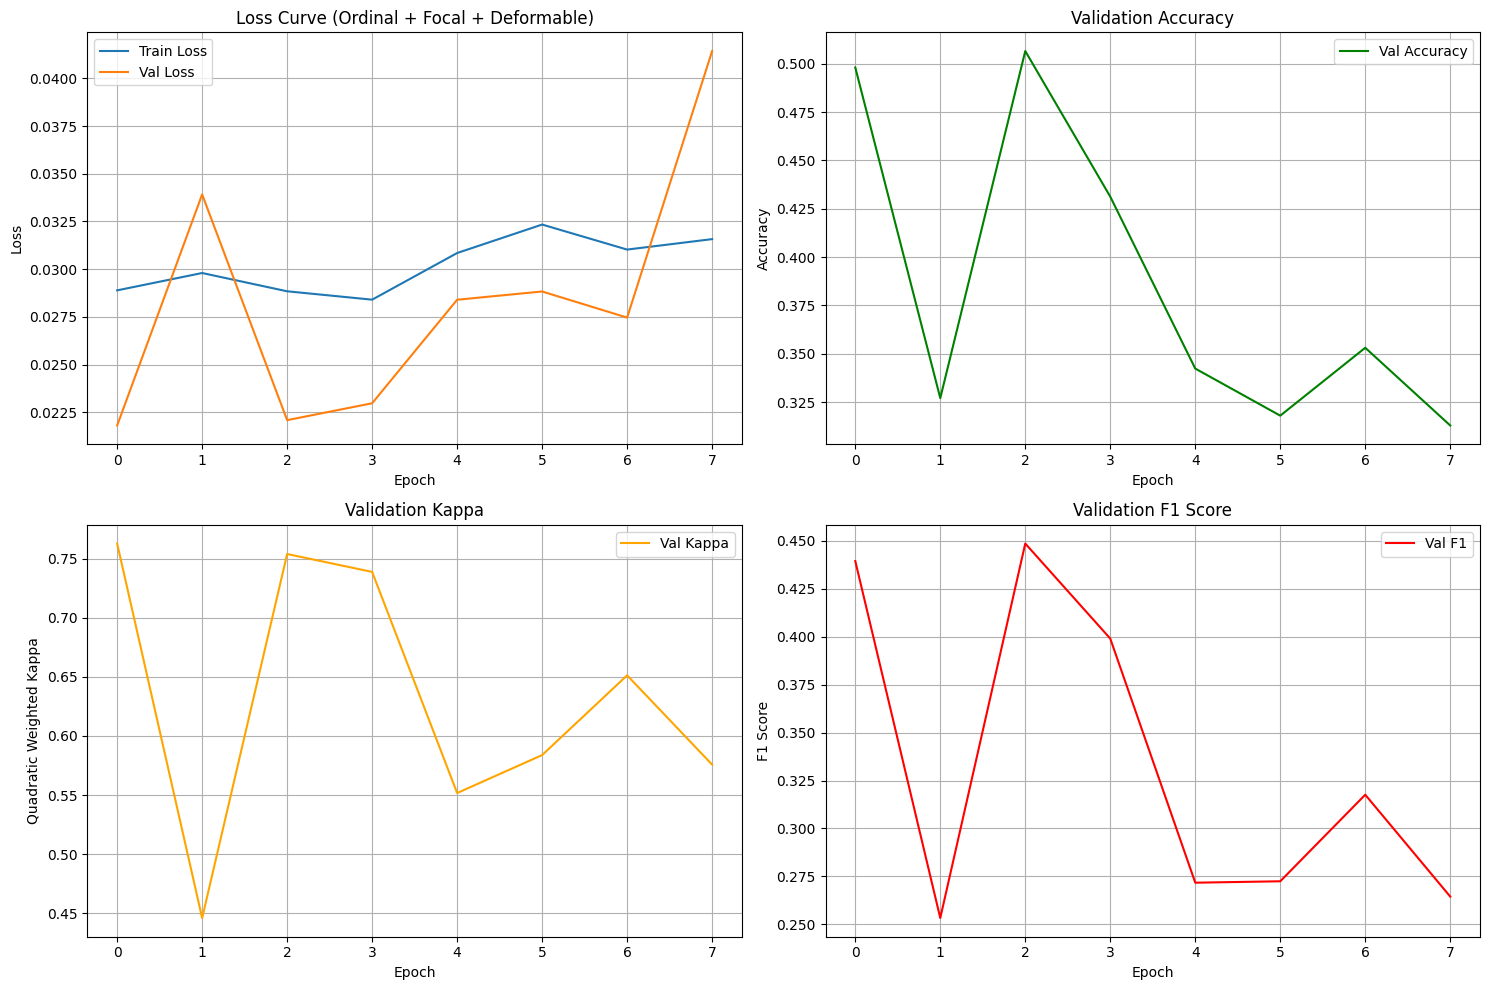

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal + Deformable)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-deformable-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 530/530 [01:38<00:00,  5.39it/s]



TEST SET RESULTS (Ordinal + Focal + Deformable)
Accuracy: 47.74%
Quadratic Weighted Kappa: 0.7508
Macro F1 Score: 0.4138

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.7252    0.5899    0.6506       434
      ISUP 1     0.4600    0.6325    0.5326       400
      ISUP 2     0.3291    0.2600    0.2905       200
      ISUP 3     0.3000    0.1784    0.2237       185
      ISUP 4     0.2671    0.2086    0.2342       187
      ISUP 5     0.4615    0.6848    0.5514       184

    accuracy                         0.4774      1590
   macro avg     0.4238    0.4257    0.4138      1590
weighted avg     0.4748    0.4774    0.4655      1590


Confusion Matrix:
[[256 148  12   7   8   3]
 [ 73 253  52  15   6   1]
 [ 12  75  52  28  17  16]
 [  5  23  24  33  51  49]
 [  3  37  13  17  39  78]
 [  4  14   5  10  25 126]]


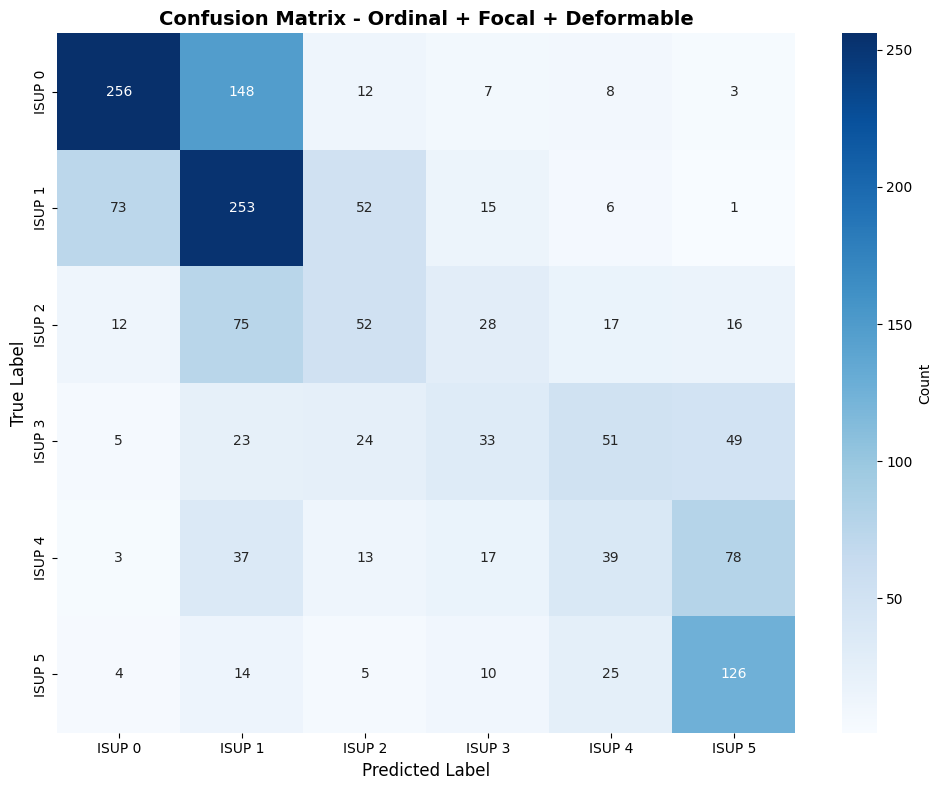

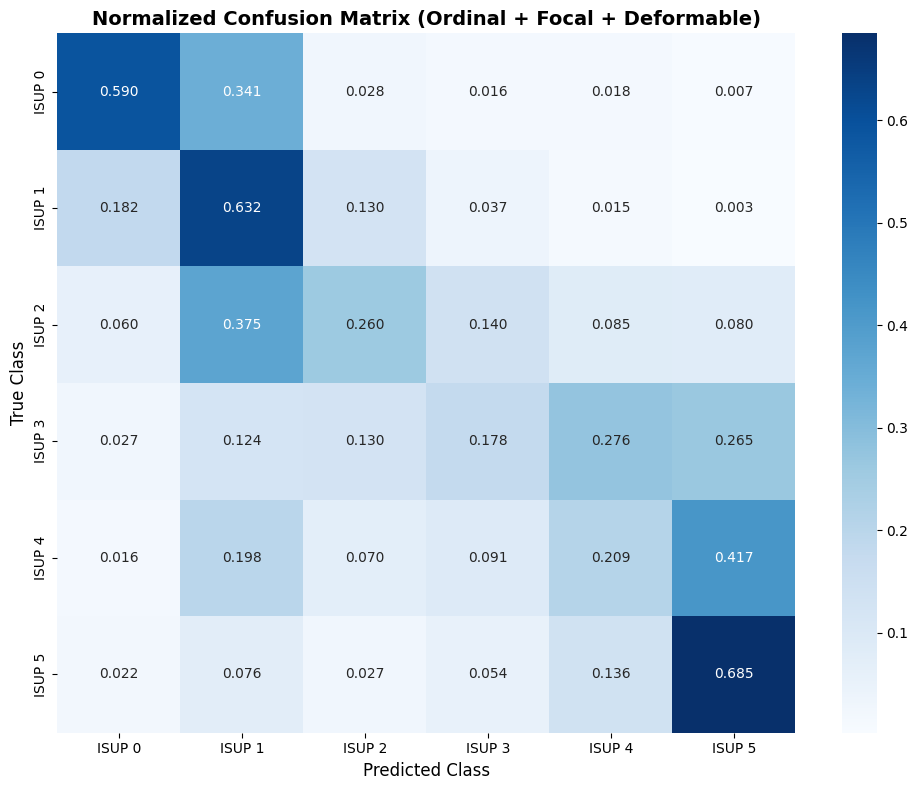


Test results saved to logs/b0-entropy-ordinal-focal-deformable-test-results.txt


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal + Deformable)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Ordinal + Focal + Deformable', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-deformable-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)]
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal + Deformable)", fontsize=14, fontweight='bold')
plt.ylabel("True Class", fontsize=12)
plt.xlabel("Predicted Class", fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-deformable-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('logs/b0-entropy-ordinal-focal-deformable-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy, Ordinal, Focal Loss, and Deformable Convolutions\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-deformable-test-results.txt")

## Summary

This notebook trained EfficientNet-B0 with a comprehensive set of advanced techniques:

### 1. Entropy Filtering
- Removed top 20% most difficult/ambiguous samples
- Cleaner training data leads to better convergence

### 2. Ordinal Loss
- Enforced natural ordering of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- Binary threshold encoding: grade k → [1,1,...,1,0,0,...,0]
- Predictions respect ordinal relationships

### 3. Focal Loss
- Down-weighted easy examples: (1-p)^gamma modulation
- Focused learning on hard misclassifications
- Better handling of class imbalance

### 4. Deformable Convolutions
- **Adaptive spatial sampling**: Learns 2D offsets for each convolution location
- **Flexible receptive fields**: Adjusts to irregular tissue structures
- **Better feature extraction**: Captures complex spatial patterns in medical images

### How Deformable Convolutions Work:

In standard convolutions, the sampling grid is fixed (e.g., 3x3 kernel always samples 9 fixed locations). 
Deformable convolutions add learnable 2D offsets to each sampling location:

```
Standard Conv:     Deformable Conv:
  ×   ×   ×           ×     ×  ×
  ×   ×   ×       ×       ×     ×
  ×   ×   ×         ×   ×    ×
```

The offsets are learned from the data through backpropagation, allowing the network to:
- Adapt to object scale and shape
- Focus on relevant spatial locations
- Model geometric transformations

### Expected Benefits:

The combination should provide:
- **Better generalization**: Cleaner data + adaptive feature extraction
- **Ordinal consistency**: Predictions follow natural grade ordering
- **Improved minority class performance**: Focal loss handles imbalance
- **Enhanced spatial modeling**: Deformable convolutions capture irregular patterns